# CNN-LOB Custom Labels at k=20

This notebook develops a paper-first custom labeling workflow for FI-2010 NoAuction ZScore data at horizon `k=20`, then trains the CNN-LOB architecture on those labels.

It keeps the model architecture aligned with the existing 2017 CNN-LOB notebook while making the label construction closer to the paper:
- labels are derived from mid-price dynamics
- only valid centers are labeled
- invalid edge rows are dropped instead of being assigned a neutral label
- labels are aligned with the final event in each `T=100` input window


## Paper Goal and Labeling Equations

We recreate the paper-style three-class labeling strategy around the future movement of the mid-price using backward and forward local averages.

For each valid event index `t` and horizon `k=20`:

- `m_minus(t)` is the mean mid-price over `[t-k, ..., t]`
- `m_plus(t)` is the mean mid-price over `[t+1, ..., t+k]`
- `l_t = 2` if `(m_plus - m_minus) / m_minus > alpha`
- `l_t = 0` if `(m_plus - m_minus) / m_minus < -alpha`
- otherwise `l_t = 1`

This notebook uses the official NoAuction ZScore FI-2010 files from `data/full/...` and keeps `k=20` fixed throughout.


In [1]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, LeakyReLU, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))


TensorFlow: 2.21.0
GPUs: []


In [2]:
K_HORIZON = 20
ALPHA = 0.0003
T = 100
VAL_RATIO = 0.20
BATCH_SIZE = 16
EPOCHS = 100
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.0
USE_CLASS_WEIGHTS = True

print({
    'k_horizon': K_HORIZON,
    'alpha': ALPHA,
    'T': T,
    'val_ratio': VAL_RATIO,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'dropout_rate': DROPOUT_RATE,
    'use_class_weights': USE_CLASS_WEIGHTS,
})


{'k_horizon': 20, 'alpha': 0.0003, 'T': 100, 'val_ratio': 0.2, 'batch_size': 16, 'epochs': 100, 'learning_rate': 0.0001, 'dropout_rate': 0.0, 'use_class_weights': True}


In [3]:
def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'data').exists():
        return cwd
    if (cwd.parent / 'data').exists():
        return cwd.parent
    raise FileNotFoundError('Could not locate repo root containing the data directory.')


def load_fi2010_noauction_zscore_k20():
    repo_root = resolve_repo_root()
    base = repo_root / 'data' / 'full' / 'BenchmarkDatasets' / 'NoAuction' / '1.NoAuction_Zscore'
    train_file = base / 'NoAuction_Zscore_Training' / 'Train_Dst_NoAuction_ZScore_CF_7.txt'
    test_files = [
        base / 'NoAuction_Zscore_Testing' / 'Test_Dst_NoAuction_ZScore_CF_7.txt',
        base / 'NoAuction_Zscore_Testing' / 'Test_Dst_NoAuction_ZScore_CF_8.txt',
        base / 'NoAuction_Zscore_Testing' / 'Test_Dst_NoAuction_ZScore_CF_9.txt',
    ]

    train_raw = np.loadtxt(train_file)
    test_raw = np.hstack([np.loadtxt(path) for path in test_files])
    return {
        'repo_root': repo_root,
        'train_file': train_file,
        'test_files': test_files,
        'train_raw': train_raw,
        'test_raw': test_raw,
    }


def split_train_validation_by_time(raw_data: np.ndarray, val_ratio: float):
    split_idx = int(np.floor(raw_data.shape[1] * (1.0 - val_ratio)))
    train_split = raw_data[:, :split_idx]
    val_split = raw_data[:, split_idx:]
    return train_split, val_split


In [4]:
def prepare_features(raw_data: np.ndarray) -> np.ndarray:
    return raw_data[:40, :].astype(np.float32, copy=False)


def compute_mid_price(features: np.ndarray) -> np.ndarray:
    """Compute the mid-price from a feature matrix of shape (40, N)."""
    if features.ndim != 2 or features.shape[0] < 4:
        raise ValueError('Expected features with shape (40, N) or compatible first dimension.')
    ask_price = features[0, :].astype(np.float64)
    bid_price = features[2, :].astype(np.float64)
    return (ask_price + bid_price) / 2.0


def compute_paper_labels(mid_price: np.ndarray, k: int = 20, alpha: float = 0.0003):
    """Return paper-style labels and a valid-index mask.

    Args:
        mid_price: 1D array with shape (N,).
        k: forecasting horizon. This notebook fixes k=20 by default.
        alpha: threshold for three-way labeling.

    Returns:
        labels: int array of shape (N,) with encoding 0=down, 1=stationary, 2=up.
            Invalid edge rows are set to -1 and must be filtered with valid_mask.
        valid_mask: bool array of shape (N,) marking indices where both backward and
            forward averaging windows exist.
    """
    mid_price = np.asarray(mid_price, dtype=np.float64)
    if mid_price.ndim != 1:
        raise ValueError('mid_price must be a 1D array.')
    if len(mid_price) <= 2 * k:
        raise ValueError('mid_price is too short for the requested horizon.')

    labels = np.full(len(mid_price), -1, dtype=np.int64)
    valid_mask = np.zeros(len(mid_price), dtype=bool)

    csum = np.concatenate(([0.0], np.cumsum(mid_price, dtype=np.float64)))
    idx = np.arange(k, len(mid_price) - k)

    past_sum = csum[idx + 1] - csum[idx - k]
    future_sum = csum[idx + k + 1] - csum[idx + 1]

    m_minus = past_sum / (k + 1)
    m_plus = future_sum / k
    rel_move = (m_plus - m_minus) / m_minus

    labels[idx] = 1
    labels[idx[rel_move > alpha]] = 2
    labels[idx[rel_move < -alpha]] = 0
    valid_mask[idx] = True
    return labels, valid_mask


def summarize_label_distribution(labels: np.ndarray, split_name: str):
    valid_labels = labels[labels >= 0]
    counts = Counter(valid_labels.tolist())
    total = len(valid_labels)
    print(f'\n{split_name} label distribution (valid rows only)')
    print('-' * 52)
    for class_id, class_name in [(0, 'down'), (1, 'stationary'), (2, 'up')]:
        count = counts.get(class_id, 0)
        pct = count / total if total else 0.0
        print(f'{class_name:<12} count={count:>8} pct={pct:>8.2%}')
    print(f'valid total : {total}')


def build_windowed_dataset(features: np.ndarray, labels: np.ndarray, valid_mask: np.ndarray, T: int):
    if features.shape[1] != len(labels) or len(labels) != len(valid_mask):
        raise ValueError('features, labels, and valid_mask must share the same event length.')

    feature_rows = features.T.astype(np.float32, copy=False)
    valid_end_indices = np.flatnonzero(valid_mask)
    valid_end_indices = valid_end_indices[valid_end_indices >= T - 1]

    windows = np.empty((len(valid_end_indices), T, feature_rows.shape[1], 1), dtype=np.float32)
    y_int = labels[valid_end_indices].astype(np.int64)

    for i, end_idx in enumerate(valid_end_indices):
        windows[i, :, :, 0] = feature_rows[end_idx - T + 1:end_idx + 1, :]

    y_cat = to_categorical(y_int, 3)
    return windows, y_int, y_cat, valid_end_indices


In [5]:
dataset = load_fi2010_noauction_zscore_k20()
train_raw_full = dataset['train_raw']
test_raw = dataset['test_raw']
train_raw, val_raw = split_train_validation_by_time(train_raw_full, VAL_RATIO)

print('Train source:', dataset['train_file'])
print('Test sources:')
for path in dataset['test_files']:
    print('  ', path)

print('\nRaw array shapes')
print('train_raw_full:', train_raw_full.shape)
print('train_raw    :', train_raw.shape)
print('val_raw      :', val_raw.shape)
print('test_raw     :', test_raw.shape)

train_features = prepare_features(train_raw)
val_features = prepare_features(val_raw)
test_features = prepare_features(test_raw)

print('\nFeature array shapes')
print('train_features:', train_features.shape)
print('val_features  :', val_features.shape)
print('test_features :', test_features.shape)


Train source: C:\Users\mateu\DeepLOB\data\full\BenchmarkDatasets\NoAuction\1.NoAuction_Zscore\NoAuction_Zscore_Training\Train_Dst_NoAuction_ZScore_CF_7.txt
Test sources:
   C:\Users\mateu\DeepLOB\data\full\BenchmarkDatasets\NoAuction\1.NoAuction_Zscore\NoAuction_Zscore_Testing\Test_Dst_NoAuction_ZScore_CF_7.txt
   C:\Users\mateu\DeepLOB\data\full\BenchmarkDatasets\NoAuction\1.NoAuction_Zscore\NoAuction_Zscore_Testing\Test_Dst_NoAuction_ZScore_CF_8.txt
   C:\Users\mateu\DeepLOB\data\full\BenchmarkDatasets\NoAuction\1.NoAuction_Zscore\NoAuction_Zscore_Testing\Test_Dst_NoAuction_ZScore_CF_9.txt

Raw array shapes
train_raw_full: (149, 254750)
train_raw    : (149, 203800)
val_raw      : (149, 50950)
test_raw     : (149, 139587)

Feature array shapes
train_features: (40, 203800)
val_features  : (40, 50950)
test_features : (40, 139587)


Mid-price lengths
train_mid: (203800,)
val_mid  : (50950,)
test_mid : (139587,)


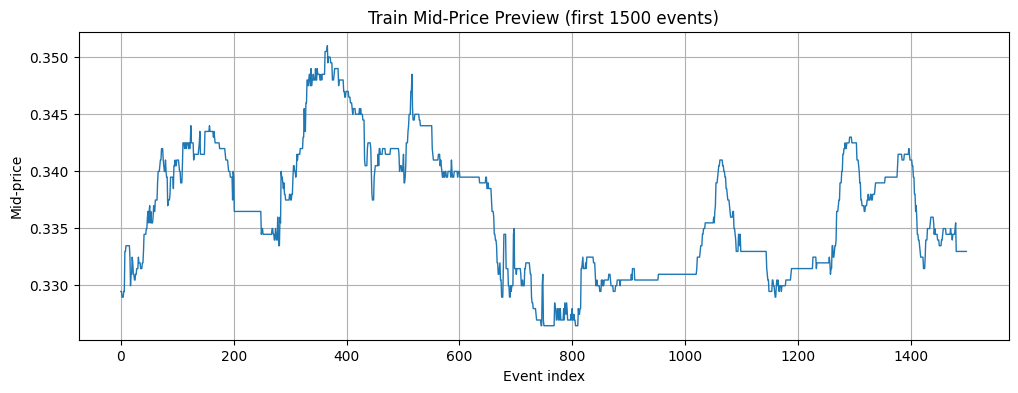

In [6]:
train_mid = compute_mid_price(train_features)
val_mid = compute_mid_price(val_features)
test_mid = compute_mid_price(test_features)

print('Mid-price lengths')
print('train_mid:', train_mid.shape)
print('val_mid  :', val_mid.shape)
print('test_mid :', test_mid.shape)

assert train_mid.shape[0] == train_features.shape[1]
assert val_mid.shape[0] == val_features.shape[1]
assert test_mid.shape[0] == test_features.shape[1]

plt.figure(figsize=(12, 4))
plt.plot(train_mid[:1500], linewidth=1.0)
plt.title('Train Mid-Price Preview (first 1500 events)')
plt.xlabel('Event index')
plt.ylabel('Mid-price')
plt.grid(True)
plt.show()


In [7]:
train_labels, train_valid_mask = compute_paper_labels(train_mid, k=K_HORIZON, alpha=ALPHA)
val_labels, val_valid_mask = compute_paper_labels(val_mid, k=K_HORIZON, alpha=ALPHA)
test_labels, test_valid_mask = compute_paper_labels(test_mid, k=K_HORIZON, alpha=ALPHA)

expected_valid = lambda n: max(n - 2 * K_HORIZON, 0)
assert train_valid_mask.sum() == expected_valid(len(train_mid))
assert val_valid_mask.sum() == expected_valid(len(val_mid))
assert test_valid_mask.sum() == expected_valid(len(test_mid))

print('Valid label counts')
print('train:', int(train_valid_mask.sum()))
print('val  :', int(val_valid_mask.sum()))
print('test :', int(test_valid_mask.sum()))

summarize_label_distribution(train_labels, 'Train')
summarize_label_distribution(val_labels, 'Validation')
summarize_label_distribution(test_labels, 'Test')


Valid label counts
train: 203760
val  : 50910
test : 139547

Train label distribution (valid rows only)
----------------------------------------------------
down         count=   81563 pct=  40.03%
stationary   count=   39225 pct=  19.25%
up           count=   82972 pct=  40.72%
valid total : 203760

Validation label distribution (valid rows only)
----------------------------------------------------
down         count=   19492 pct=  38.29%
stationary   count=   12334 pct=  24.23%
up           count=   19084 pct=  37.49%
valid total : 50910

Test label distribution (valid rows only)
----------------------------------------------------
down         count=   45729 pct=  32.77%
stationary   count=   46735 pct=  33.49%
up           count=   47083 pct=  33.74%
valid total : 139547


In [8]:
trainX, train_y_int, trainY, train_end_idx = build_windowed_dataset(train_features, train_labels, train_valid_mask, T)
valX, val_y_int, valY, val_end_idx = build_windowed_dataset(val_features, val_labels, val_valid_mask, T)
testX, test_y_int, testY, test_end_idx = build_windowed_dataset(test_features, test_labels, test_valid_mask, T)

print('Windowed dataset shapes')
print('trainX:', trainX.shape, 'trainY:', trainY.shape)
print('valX  :', valX.shape, 'valY  :', valY.shape)
print('testX :', testX.shape, 'testY :', testY.shape)

assert trainX.shape[0] == trainY.shape[0] == len(train_y_int) == len(train_end_idx)
assert valX.shape[0] == valY.shape[0] == len(val_y_int) == len(val_end_idx)
assert testX.shape[0] == testY.shape[0] == len(test_y_int) == len(test_end_idx)
assert np.all(train_end_idx >= T - 1)
assert np.all(val_end_idx >= T - 1)
assert np.all(test_end_idx >= T - 1)

print('\nWindow-aligned class counts')
print('Train:', Counter(train_y_int.tolist()))
print('Val  :', Counter(val_y_int.tolist()))
print('Test :', Counter(test_y_int.tolist()))


Windowed dataset shapes
trainX: (203681, 100, 40, 1) trainY: (203681, 3)
valX  : (50831, 100, 40, 1) valY  : (50831, 3)
testX : (139468, 100, 40, 1) testY : (139468, 3)

Window-aligned class counts
Train: Counter({2: 82905, 0: 81556, 1: 39220})
Val  : Counter({0: 19477, 2: 19041, 1: 12313})
Test : Counter({2: 47004, 1: 46735, 0: 45729})


## CNN-LOB Model

The architecture stays aligned with the existing CNN-LOB notebook. The main change in this notebook is the paper-style label generation and dataset alignment, not the network design.


In [9]:
def create_cnnlob(T: int, NF: int, learning_rate: float = 1e-4, dropout_rate: float = 0.0):
    input_lmd = Input(shape=(T, NF, 1))

    x = Conv2D(16, (4, NF), padding='valid')(input_lmd)
    x = LeakyReLU(negative_slope=0.01)(x)

    x = Conv2D(16, (4, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)

    x = MaxPooling2D(pool_size=(2, 1))(x)

    x = Conv2D(32, (3, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)

    x = Conv2D(32, (3, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)

    x = MaxPooling2D(pool_size=(2, 1))(x)

    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)

    x = Flatten()(x)
    x = Dense(32)(x)
    x = LeakyReLU(negative_slope=0.01)(x)

    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)

    out = Dense(3, activation='softmax')(x)

    model = Model(inputs=input_lmd, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


cnnlob = create_cnnlob(T=T, NF=trainX.shape[2], learning_rate=LEARNING_RATE, dropout_rate=DROPOUT_RATE)
cnnlob.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 40, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 97, 1, 16)      │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 97, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 94, 1, 16)      │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 94, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 1, 32)      │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 45, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 43, 1, 32)      │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 43, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 21, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 672)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        21,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,923 (116.89 KB)

 Trainable params: 29,923 (116.89 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
%%time
repo_root = dataset['repo_root']
model_dir = repo_root / 'jupyter_tensorflow' / 'model_cnnlob_2017'
model_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = model_dir / 'weights_custom_labels_paper_k20_zscore.weights.h5'

class_weights = None
if USE_CLASS_WEIGHTS:
    cw = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=train_y_int)
    class_weights = {0: float(cw[0]), 1: float(cw[1]), 2: float(cw[2])}

print('Class weights:', class_weights)
print('Checkpoint:', checkpoint_path)

callbacks = [
    ModelCheckpoint(
        filepath=str(checkpoint_path),
        save_weights_only=True,
        monitor='val_loss',
        save_best_only=True,
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
    ),
]

history = cnnlob.fit(
    trainX,
    trainY,
    validation_data=(valX, valY),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
    class_weight=class_weights,
    callbacks=callbacks,
)


Class weights: {0: 0.832479114555234, 1: 1.7310980792112867, 2: 0.8189333172506684}
Checkpoint: C:\Users\mateu\DeepLOB\jupyter_tensorflow\model_cnnlob_2017\weights_custom_labels_paper_k20_zscore.weights.h5


Epoch 1/100


12731/12731 - 34s - 3ms/step - accuracy: 0.4053 - loss: 1.0458 - val_accuracy: 0.3399 - val_loss: 1.1064


Epoch 2/100


12731/12731 - 33s - 3ms/step - accuracy: 0.4727 - loss: 1.0056 - val_accuracy: 0.4101 - val_loss: 1.0835


...

Epoch 19/100


12731/12731 - 33s - 3ms/step - accuracy: 0.6768 - loss: 0.7344 - val_accuracy: 0.4377 - val_loss: 1.1253


Epoch 20/100


12731/12731 - 33s - 3ms/step - accuracy: 0.6819 - loss: 0.7249 - val_accuracy: 0.4368 - val_loss: 1.1307


CPU times: total: 1h 17min 11s
Wall time: 10min 55s


   1/8717 ━━━━━━━━━━━━━━━━━━━━ 6:08 42ms/step

  37/8717 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step  

  82/8717 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step

 128/8717 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step

 175/8717 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step 

...

8614/8717 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step

8667/8717 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step

8717/8717 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step

8717/8717 ━━━━━━━━━━━━━━━━━━━━ 9s 996us/step


Test accuracy      : 0.4538
Macro F1           : 0.4469
Weighted F1        : 0.4475
Majority baseline  : 0.3370 (class 2)

Classification report
              precision    recall  f1-score   support

           0     0.4793    0.3076    0.3747     45729
           1     0.4620    0.5154    0.4872     46735
           2     0.4335    0.5347    0.4788     47004

    accuracy                         0.4538    139468
   macro avg     0.4582    0.4526    0.4469    139468
weighted avg     0.4580    0.4538    0.4475    139468



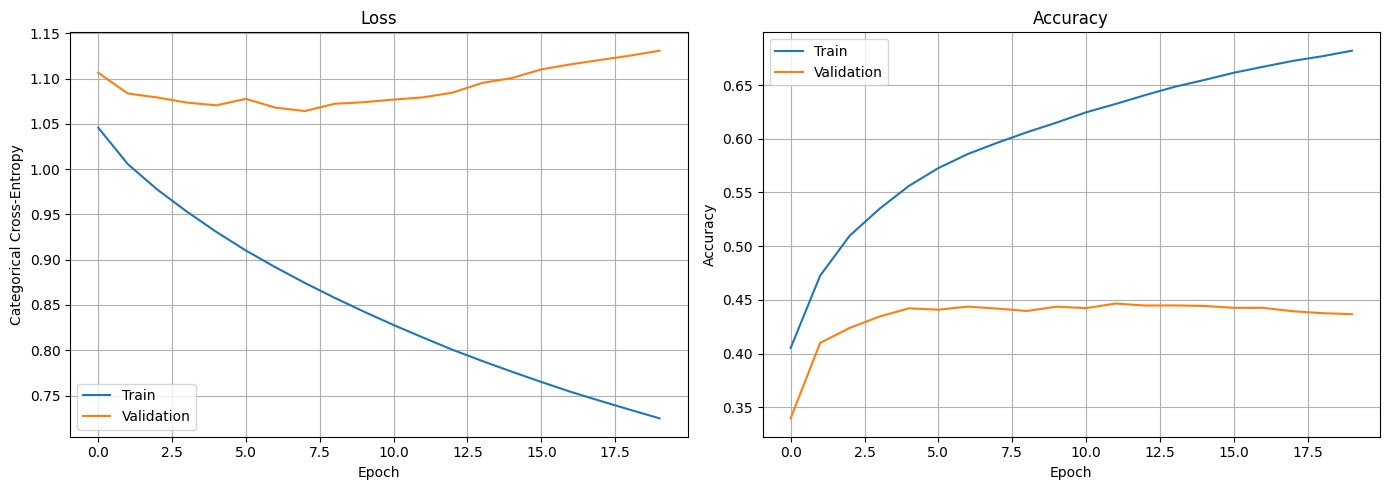

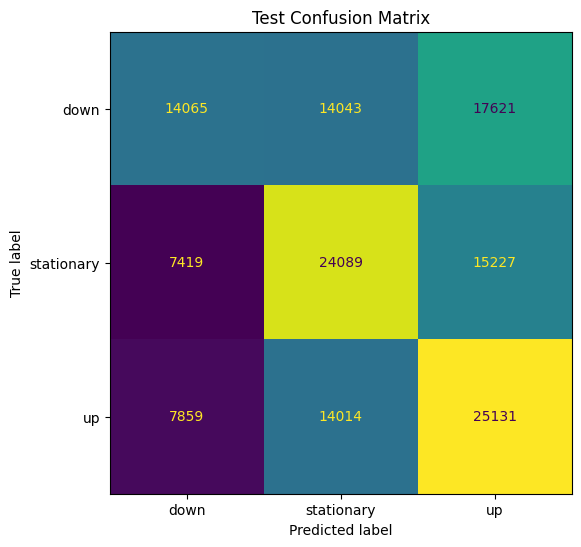

In [11]:
cnnlob.load_weights(checkpoint_path)
pred = cnnlob.predict(testX, batch_size=BATCH_SIZE, verbose=1)
pred_int = np.argmax(pred, axis=1)

report_text = classification_report(test_y_int, pred_int, digits=4)
report_dict = classification_report(test_y_int, pred_int, digits=4, output_dict=True)
acc = accuracy_score(test_y_int, pred_int)
macro_f1 = report_dict['macro avg']['f1-score']
weighted_f1 = report_dict['weighted avg']['f1-score']
majority_class = Counter(train_y_int.tolist()).most_common(1)[0][0]
majority_acc = float((test_y_int == majority_class).mean())

print(f'Test accuracy      : {acc:.4f}')
print(f'Macro F1           : {macro_f1:.4f}')
print(f'Weighted F1        : {weighted_f1:.4f}')
print(f'Majority baseline  : {majority_acc:.4f} (class {majority_class})')
print('\nClassification report')
print(report_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Cross-Entropy')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

cm = confusion_matrix(test_y_int, pred_int, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['down', 'stationary', 'up']).plot(ax=ax, colorbar=False)
ax.set_title('Test Confusion Matrix')
plt.show()
